<a href="https://colab.research.google.com/github/suedasmn/suedasmn/blob/main/gazi_lisansustu_danisman_projesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y torchao -q
!pip install -q -U transformers accelerate peft datasets gradio chromadb sentence-transformers pymupdf scikit-learn joblib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.3/32.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/7

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import json
import re
import warnings
warnings.filterwarnings("ignore")

PROJECT_DIR = "/content/drive/MyDrive/gazi_lisansustu_danisman"

DATA_DIR = f"{PROJECT_DIR}/data"
PROCESSED_DIR = f"{PROJECT_DIR}/processed"
MODEL_DIR = f"{PROJECT_DIR}/models"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

FORCE_RETRAIN_LORA = False
TRAINING_VERSION = "v2_genisletilmis_ft_31_ornek_guvenli_katman"

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("\nData klasörü dosyaları:")
print(os.listdir(DATA_DIR))


Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/gazi_lisansustu_danisman
DATA_DIR: /content/drive/MyDrive/gazi_lisansustu_danisman/data
PROCESSED_DIR: /content/drive/MyDrive/gazi_lisansustu_danisman/processed
MODEL_DIR: /content/drive/MyDrive/gazi_lisansustu_danisman/models

Data klasörü dosyaları:
['akademik_takvim_2025_2026.pdf', 'yuksek_lisans_uygulama_esaslari.pdf', 'lisansustu_yonetmelik.pdf', 'bilgisayar_muhendisligi_basvuru_kriterleri.pdf', 'gazi_logo.png']


In [3]:
import fitz


pdf_files = [
    {"file_name":"yuksek_lisans_uygulama_esaslari.pdf","document_name":"Gazi Üniversitesi Yüksek Lisans Eğitim-Öğretim Uygulama Esasları","document_type":"Uygulama Esasları","category":"Yüksek Lisans"},
    {"file_name":"lisansustu_yonetmelik.pdf","document_name":"Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği","document_type":"Yönetmelik","category":"Lisansüstü"},
    {"file_name":"akademik_takvim_2025_2026.pdf","document_name":"Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi","document_type":"Akademik Takvim","category":"Takvim"},
    {"file_name":"bilgisayar_muhendisligi_basvuru_kriterleri.pdf","document_name":"Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri","document_type":"Başvuru Kriterleri","category":"Bilgisayar Mühendisliği"}
]


documents_text_path = f"{PROCESSED_DIR}/documents_text.json"


if os.path.exists(documents_text_path):
    with open(documents_text_path, "r", encoding="utf-8") as f:
        documents = json.load(f)
    print("documents_text.json bulundu.")
else:

    documents = []
    for pdf_info in pdf_files:
        pdf_path = os.path.join(DATA_DIR, pdf_info["file_name"])
        if not os.path.exists(pdf_path):
            print("Dosya bulunamadı:", pdf_info["file_name"])
            continue
        doc = fitz.open(pdf_path)
        full_text = ""
        for page_number, page in enumerate(doc, start=1):
            full_text += f"\n\n--- Sayfa {page_number} ---\n" + page.get_text("text")
        documents.append({**pdf_info, "page_count": len(doc), "text": full_text})
        print("Okundu:", pdf_info["file_name"], "|", len(doc), "sayfa")
    with open(documents_text_path, "w", encoding="utf-8") as f:
        json.dump(documents, f, ensure_ascii=False, indent=2)
print("Belge sayısı:", len(documents))
if len(documents) == 0:
    raise FileNotFoundError(
        "Hiç belge yüklenemedi. Lütfen PDF dosyalarının DATA_DIR içinde ve beklenen dosya adlarıyla bulunduğunu kontrol et."
    )


documents_text.json bulundu.
Belge sayısı: 4


In [4]:
def clean_text(text):
    text = re.sub(r"\s+", " ", text)
    text = text.replace("--- Sayfa", "\n--- Sayfa")
    return text.strip()


def split_text_smart(text, max_chunk_size=1200, overlap_sentences=1):
    text = clean_text(text)
    sentences = re.split(r"(?<=[.!?])\s+", text)
    chunks, current_chunk = [], []
    for sentence in sentences:
        temp = " ".join(current_chunk + [sentence])
        if len(temp) <= max_chunk_size:
            current_chunk.append(sentence)
        else:
            if current_chunk:
                chunks.append(" ".join(current_chunk).strip())
                current_chunk = current_chunk[-overlap_sentences:] + [sentence]
            else:
                chunks.append(sentence.strip())
                current_chunk = []
    if current_chunk:
        chunks.append(" ".join(current_chunk).strip())
    return [c for c in chunks if len(c) > 100]


all_chunks = []
for doc in documents:
    for i, chunk_text in enumerate(split_text_smart(doc["text"]), start=1):
        all_chunks.append({
            "chunk_id": f"{doc['file_name']}_chunk_{i}",
            "document_name": doc["document_name"],
            "document_type": doc["document_type"],
            "category": doc["category"],
            "file_name": doc["file_name"],
            "chunk_number": i,
            "text": chunk_text
        })



manual_chunks = [
    {
        "chunk_id": "manual_basvuru_degerlendirme_oranlari",
        "document_name": "Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri",
        "document_type": "Başvuru Kriterleri",
        "category": "Bilgisayar Mühendisliği",
        "file_name": "bilgisayar_muhendisligi_basvuru_kriterleri.pdf",
        "chunk_number": 1001,
        "text": """
Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği 2025-2026 Bahar Yarıyılı yüksek lisans başvuru kriterlerine göre değerlendirme oranları şu şekildedir: ALES %50, yabancı dil %10, lisans not ortalaması AGNO %10 ve yazılı sınav %30 oranında etkilidir.
"""
    },
    {
        "chunk_id": "manual_yazili_sinav_tarihi_yeri",
        "document_name": "Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri",
        "document_type": "Başvuru Kriterleri",
        "category": "Bilgisayar Mühendisliği",
        "file_name": "bilgisayar_muhendisligi_basvuru_kriterleri.pdf",
        "chunk_number": 1002,
        "text": """
Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği 2025-2026 Bahar Yarıyılı başvuru kriterleri belgesine göre yüksek lisans yazılı sınavı 13.01.2026 tarihinde saat 10.00'da yapılacaktır. Sınav yeri Bilgisayar Mühendisliği Bölümü No:B-443 olarak belirtilmiştir.
"""
    },
    {
        "chunk_id": "manual_basvurabilecek_bolumler",
        "document_name": "Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri",
        "document_type": "Başvuru Kriterleri",
        "category": "Bilgisayar Mühendisliği",
        "file_name": "bilgisayar_muhendisligi_basvuru_kriterleri.pdf",
        "chunk_number": 1003,
        "text": """
Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği yüksek lisans programına başvuru kabul edilen lisans programları şunlardır: Bilgisayar Bilimleri ve Mühendisliği, Bilgisayar Mühendisliği, Bilgisayar ve Yazılım Mühendisliği, Elektrik-Elektronik Mühendisliği, Kontrol ve Bilgisayar Mühendisliği, Yazılım Mühendisliği, Yapay Zeka Mühendisliği ve Yapay Zeka ve Veri Mühendisliği.
"""
    },
    {
        "chunk_id": "manual_akademik_takvim_ders_kayitlari",
        "document_name": "Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi",
        "document_type": "Akademik Takvim",
        "category": "Takvim",
        "file_name": "akademik_takvim_2025_2026.pdf",
        "chunk_number": 2001,
        "text": """
Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi'ne göre güz yarıyılı ders kayıtları 11-15 Eylül 2025 tarihleri arasında, bahar yarıyılı ders kayıtları ise 2-4 Şubat 2026 tarihleri arasında yapılacaktır.
"""
    },
    {
        "chunk_id": "manual_akademik_takvim_danisman_onaylari",
        "document_name": "Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi",
        "document_type": "Akademik Takvim",
        "category": "Takvim",
        "file_name": "akademik_takvim_2025_2026.pdf",
        "chunk_number": 2002,
        "text": """
Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi'ne göre güz yarıyılı etkileşimli danışman onayları 16-17 Eylül 2025 tarihleri arasında, bahar yarıyılı etkileşimli danışman onayları ise 5-6 Şubat 2026 tarihleri arasında yapılacaktır.
"""
    },
    {
        "chunk_id": "manual_akademik_takvim_ders_baslangic",
        "document_name": "Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi",
        "document_type": "Akademik Takvim",
        "category": "Takvim",
        "file_name": "akademik_takvim_2025_2026.pdf",
        "chunk_number": 2003,
        "text": """
Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi'ne göre güz yarıyılı dersleri 22 Eylül 2025 tarihinde, bahar yarıyılı dersleri ise 9 Şubat 2026 tarihinde başlamaktadır.
"""
    },
    {
        "chunk_id": "manual_akademik_takvim_ders_ekleme_birakma",
        "document_name": "Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi",
        "document_type": "Akademik Takvim",
        "category": "Takvim",
        "file_name": "akademik_takvim_2025_2026.pdf",
        "chunk_number": 2004,
        "text": """
Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi'ne göre güz yarıyılı ders ekleme-bırakma işlemleri 2-3 Ekim 2025 tarihleri arasında, bahar yarıyılı ders ekleme-bırakma işlemleri ise 19-20 Şubat 2026 tarihleri arasında yapılacaktır.
"""
    },
    {
        "chunk_id": "manual_akademik_takvim_donem_sonu_sinavlari",
        "document_name": "Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi",
        "document_type": "Akademik Takvim",
        "category": "Takvim",
        "file_name": "akademik_takvim_2025_2026.pdf",
        "chunk_number": 2005,
        "text": """
Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi'ne göre güz yarıyılı dönem sonu sınavları 2-11 Ocak 2026 tarihleri arasında, bahar yarıyılı dönem sonu sınavları ise 1-14 Haziran 2026 tarihleri arasında yapılacaktır.
"""
    },
    {
        "chunk_id": "manual_yonetmelik_tezli_yuksek_lisans_suresi",
        "document_name": "Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği",
        "document_type": "Yönetmelik",
        "category": "Lisansüstü",
        "file_name": "lisansustu_yonetmelik.pdf",
        "chunk_number": 3001,
        "text": """
Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği'ne göre tezli yüksek lisans programının süresi, bilimsel hazırlıkta geçen süre hariç dört yarıyıldır. Program en çok altı yarıyılda tamamlanır.
"""
    },
    {
        "chunk_id": "manual_yonetmelik_kredi_sartlari",
        "document_name": "Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği",
        "document_type": "Yönetmelik",
        "category": "Lisansüstü",
        "file_name": "lisansustu_yonetmelik.pdf",
        "chunk_number": 3002,
        "text": """
Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği'ne göre tezsiz yüksek lisans programı için en az 90 kredi, tezli yüksek lisans programı için en az 120 kredi gerekir.
"""
    },
    {
        "chunk_id": "manual_yonetmelik_kayit_yenilememe",
        "document_name": "Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği",
        "document_type": "Yönetmelik",
        "category": "Lisansüstü",
        "file_name": "lisansustu_yonetmelik.pdf",
        "chunk_number": 3003,
        "text": """
Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği'ne göre akademik takvimde belirtilen sürede kaydını yenilemeyen öğrenci o yarıyılda derslere ve sınavlara giremez.
"""
    },
    {
        "chunk_id": "manual_yonetmelik_ayni_anda_kayit",
        "document_name": "Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği",
        "document_type": "Yönetmelik",
        "category": "Lisansüstü",
        "file_name": "lisansustu_yonetmelik.pdf",
        "chunk_number": 3004,
        "text": """
Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği'ne göre tezsiz yüksek lisans programları hariç, aynı anda birden fazla lisansüstü programa kayıt yaptırılamaz ve devam edilemez.
"""
    }
]


existing_ids = {chunk["chunk_id"] for chunk in all_chunks}

for chunk in manual_chunks:
    if chunk["chunk_id"] not in existing_ids:
        all_chunks.append(chunk)

print("Manuel yapılandırılmış chunklar eklendi.")
print("Toplam chunk sayısı:", len(all_chunks))

chunks_path = f"{PROCESSED_DIR}/chunks.json"
with open(chunks_path, "w", encoding="utf-8") as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=2)
print("Chunk sayısı:", len(all_chunks))


Manuel yapılandırılmış chunklar eklendi.
Toplam chunk sayısı: 61
Chunk sayısı: 61


Soru Sınıflandırma Modeli Başarı Metrikleri
              Metrik    Değer
            Accuracy 0.705882
   Precision (Macro) 0.708333
      Recall (Macro) 0.688889
    F1-Score (Macro) 0.682540
Precision (Weighted) 0.710784
   Recall (Weighted) 0.705882
 F1-Score (Weighted) 0.693277

Sınıf Bazlı Classification Report
              precision    recall  f1-score   support

     basvuru       0.62      0.83      0.71         6
      takvim       0.83      0.83      0.83         6
  yonetmelik       0.67      0.40      0.50         5

    accuracy                           0.71        17
   macro avg       0.71      0.69      0.68        17
weighted avg       0.71      0.71      0.69        17


Confusion Matrix
                    Tahmin: basvuru  Tahmin: takvim  Tahmin: yonetmelik
Gerçek: basvuru                   5               0                   1
Gerçek: takvim                    1               5                   0
Gerçek: yonetmelik                2               1               

<Figure size 600x500 with 0 Axes>

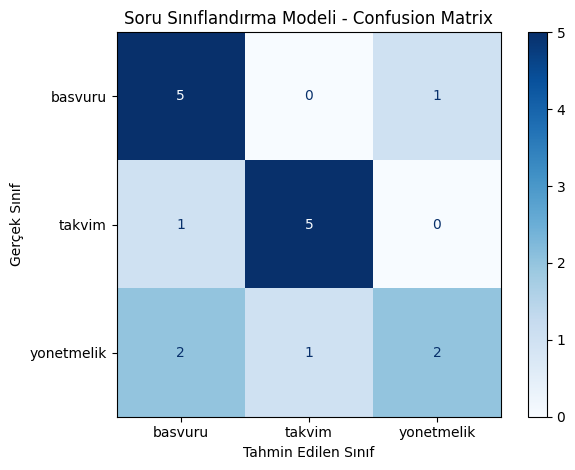


Kaydedilen dosyalar
Model: /content/drive/MyDrive/gazi_lisansustu_danisman/models/question_classifier.pkl
Metrikler: /content/drive/MyDrive/gazi_lisansustu_danisman/processed/question_classifier_metrics.csv
Confusion Matrix Görseli: /content/drive/MyDrive/gazi_lisansustu_danisman/processed/question_classifier_confusion_matrix.png


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import os


training_data = [

    ("ALES puanı başvuruda ne kadar etkili?", "basvuru"),
    ("ALES değerlendirme oranı kaçtır?", "basvuru"),
    ("Yabancı dil puanı başvuruda etkili mi?", "basvuru"),
    ("Yabancı dil oranı kaç?", "basvuru"),
    ("Lisans not ortalaması başvuruda ne kadar etkili?", "basvuru"),
    ("AGNO başvuru değerlendirmesinde kaç puan etkili?", "basvuru"),
    ("Yazılı sınav başvuruda ne kadar etkili?", "basvuru"),
    ("Yüksek lisans yazılı sınavı ne zaman?", "basvuru"),
    ("Bilgisayar mühendisliği yüksek lisansına hangi bölümler başvurabilir?", "basvuru"),
    ("Hangi lisans mezunları bilgisayar mühendisliği yüksek lisansına başvurabilir?", "basvuru"),
    ("Başvuru kabul edilen lisans programları nelerdir?", "basvuru"),
    ("Bilgisayar mühendisliği yüksek lisans başvuru şartları nelerdir?", "basvuru"),
    ("Yüksek lisansa başvuru kriterleri nelerdir?", "basvuru"),
    ("Başvuru için hangi şartlar aranıyor?", "basvuru"),
    ("Başvuru değerlendirmesi nasıl yapılır?", "basvuru"),


    ("Ders kayıtları ne zaman yapılacak?", "takvim"),
    ("Güz dönemi ders kayıtları hangi tarihte?", "takvim"),
    ("Bahar dönemi ders kayıtları ne zaman?", "takvim"),
    ("Danışman onayı ne zaman yapılır?", "takvim"),
    ("Etkileşimli danışman onayları hangi tarihler arasında?", "takvim"),
    ("Güz yarıyılı ne zaman başlıyor?", "takvim"),
    ("Bahar yarıyılı ne zaman başlıyor?", "takvim"),
    ("Dönem sonu sınavları ne zaman?", "takvim"),
    ("Final sınavları hangi tarihte?", "takvim"),
    ("Akademik takvimde ders başlangıcı ne zaman?", "takvim"),
    ("Ders ekleme bırakma tarihleri ne zaman?", "takvim"),
    ("Bahar dönemi danışman onayı hangi tarihlerde?", "takvim"),
    ("Güz dönemi danışman onayı ne zaman?", "takvim"),


    ("Tezli yüksek lisans süresi kaç yarıyıldır?", "yonetmelik"),
    ("Yüksek lisans en fazla kaç dönemde tamamlanır?", "yonetmelik"),
    ("Tez danışmanı ne zaman atanır?", "yonetmelik"),
    ("Danışman atanması nasıl yapılır?", "yonetmelik"),
    ("Tez konusu ne zaman belirlenir?", "yonetmelik"),
    ("Mezuniyet şartları nelerdir?", "yonetmelik"),
    ("Yüksek lisans için kaç kredi gerekir?", "yonetmelik"),
    ("Tezli yüksek lisans toplam kredisi kaçtır?", "yonetmelik"),
    ("Başarısız olunan ders tekrar alınabilir mi?", "yonetmelik"),
    ("Yüksek lisans dersinden başarılı olmak için hangi not gerekir?", "yonetmelik"),
    ("Kayıt yenilemeyen öğrenci ne olur?", "yonetmelik"),
    ("Aynı anda birden fazla lisansüstü programa kayıt yapılabilir mi?", "yonetmelik"),
    ("Bilimsel hazırlık nedir?", "yonetmelik")
]

questions = [x[0] for x in training_data]
labels = [x[1] for x in training_data]


X_train, X_test, y_train, y_test = train_test_split(
    questions,
    labels,
    test_size=0.40,
    random_state=42,
    stratify=labels
)



question_classifier = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        max_features=1000
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])



question_classifier.fit(X_train, y_train)



y_pred = question_classifier.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
precision_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)

metrics_df = pd.DataFrame({
    "Metrik": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-Score (Macro)",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-Score (Weighted)"
    ],
    "Değer": [
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted
    ]
})

print("Soru Sınıflandırma Modeli Başarı Metrikleri")
print("=" * 60)
print(metrics_df.to_string(index=False))

print("\nSınıf Bazlı Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred, zero_division=0))


class_names = question_classifier.classes_
cm = confusion_matrix(y_test, y_pred, labels=class_names)

print("\nConfusion Matrix")
print("=" * 60)
cm_df = pd.DataFrame(cm, index=[f"Gerçek: {c}" for c in class_names], columns=[f"Tahmin: {c}" for c in class_names])
print(cm_df)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(values_format="d", cmap="Blues")
plt.title("Soru Sınıflandırma Modeli - Confusion Matrix")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.tight_layout()

confusion_matrix_path = f"{PROCESSED_DIR}/question_classifier_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()


metrics_path = f"{PROCESSED_DIR}/question_classifier_metrics.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")


classifier_path = f"{MODEL_DIR}/question_classifier.pkl"
joblib.dump(question_classifier, classifier_path)

print("\nKaydedilen dosyalar")
print("=" * 60)
print("Model:", classifier_path)
print("Metrikler:", metrics_path)
print("Confusion Matrix Görseli:", confusion_matrix_path)


In [6]:
from sentence_transformers import SentenceTransformer
import chromadb


embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")


client = chromadb.EphemeralClient()
collection = client.get_or_create_collection(name="gazi_lisansustu_chunks")


ids = [c["chunk_id"] for c in all_chunks]
texts = [c["text"] for c in all_chunks]
metadatas = [
    {
        "document_name": c["document_name"],
        "document_type": c["document_type"],
        "category": c["category"],
        "file_name": c["file_name"],
        "chunk_number": c["chunk_number"]
    }
    for c in all_chunks
]


if len(ids) != len(set(ids)):
    raise ValueError("Chunk ID tekrarları var. Lütfen chunk_id değerlerini kontrol et.")


embeddings = embedding_model.encode(texts, show_progress_bar=True).tolist()


collection.add(
    ids=ids,
    documents=texts,
    metadatas=metadatas,
    embeddings=embeddings
)

print("ChromaDB hazır.")
print("Eklenen chunk sayısı:", len(ids))


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

ChromaDB hazır.
Eklenen chunk sayısı: 61


In [7]:
def detect_query_type(query):
    """
    Soru türünü belirler.
    Önce kritik anahtar kelimelerle güvenli kural kontrolü yapılır.
    Kural yakalayamazsa eğitilmiş TF-IDF + Logistic Regression modeli kullanılır.
    """
    q = query.lower()


    if any(x in q for x in [
        "ales", "başvuru", "basvuru", "yazılı sınav", "yazili sinav",
        "hangi bölümler", "hangi bolumler", "hangi lisans",
        "başvurabilir", "basvurabilir", "kimler başvurabilir", "kimler basvurabilir",
        "yabancı dil", "yabanci dil", "agno", "kontenjan"
    ]):
        return "basvuru"


    if any(x in q for x in [
        "ders kayıt", "ders kaydı", "ders kayit", "ders kaydi",
        "danışman onayı", "danisman onayi", "danışman onay", "danisman onay",
        "akademik takvim", "dönem ne zaman", "donem ne zaman",
        "güz yarıyılı", "guz yariyili", "bahar yarıyılı", "bahar yariyili",
        "final", "dönem sonu", "donem sonu", "ders başlangıcı", "ders baslangici"
    ]):
        return "takvim"


    if any(x in q for x in [
        "tez", "kredi", "mezuniyet", "süre", "sure", "yarıyıl", "yariyil",
        "başarı", "basari", "kayıt yenilemeyen", "kayit yenilemeyen",
        "ilişik kesme", "ilisik kesme", "bilimsel hazırlık", "bilimsel hazirlik"
    ]):
        return "yonetmelik"


    try:
        return question_classifier.predict([query])[0]
    except Exception:
        return "genel"



def improve_query(query):
    query_type = detect_query_type(query)

    if query_type == "basvuru":
        return query + " başvuru kriterleri bilgisayar mühendisliği yüksek lisans ALES yabancı dil AGNO yazılı sınav değerlendirme oran kabul edilen lisans programları"

    if query_type == "takvim":
        return query + " akademik takvim lisansüstü ders kayıt danışman onayı tarih güz bahar yarıyılı dönem sonu"

    if query_type == "yonetmelik":
        return query + " lisansüstü yönetmelik yüksek lisans tez kredi süre başarı mezuniyet danışman bilimsel hazırlık"

    return query



def keyword_score(query, text, metadata):
    query_lower, text_lower = query.lower(), text.lower()
    doc_name_lower, doc_type_lower = metadata["document_name"].lower(), metadata["document_type"].lower()

    score = 0
    query_type = detect_query_type(query)

    important_words = [
        "ales", "başvuru", "yazılı", "sınav", "yabancı dil", "agno",
        "değerlendirme", "bilgisayar mühendisliği", "yüksek lisans",
        "ders kayıt", "danışman onayı", "tez", "kredi", "mezuniyet",
        "süre", "yarıyıl"
    ]

    for word in important_words:
        if word in query_lower and word in text_lower:
            score += 3

    if query_type == "basvuru":
        if "başvuru kriterleri" in doc_name_lower or "başvuru kriterleri" in doc_type_lower:
            score += 25
        if "bilgisayar mühendisliği" in doc_name_lower:
            score += 12

    if query_type == "takvim":
        if "akademik takvim" in doc_name_lower or "akademik takvim" in doc_type_lower:
            score += 25

    if query_type == "yonetmelik":
        if "yönetmelik" in doc_name_lower or "yönetmelik" in doc_type_lower:
            score += 15
        if "uygulama esasları" in doc_name_lower or "uygulama esasları" in doc_type_lower:
            score += 5


    if "yazılı sınav" in query_lower or "yazili sinav" in query_lower:
        if "13.01.2026" in text_lower or "saat 10.00" in text_lower or "sınav yeri" in text_lower:
            score += 35
        if "%30" in text_lower:
            score -= 5

    if "ales" in query_lower or "ne kadar etkili" in query_lower:
        if "%50" in text_lower or "ales %50" in text_lower:
            score += 35

    if "hangi bölümler" in query_lower or "hangi bolumler" in query_lower or "başvurabilir" in query_lower or "basvurabilir" in query_lower:
        if "bilgisayar bilimleri ve mühendisliği" in text_lower and "yapay zeka" in text_lower:
            score += 35

    if "ders kayıt" in query_lower or "ders kaydı" in query_lower:
        if "11-15 eylül 2025" in text_lower or "2-4 şubat 2026" in text_lower:
            score += 35

    if "danışman onayı" in query_lower or "danisman onayi" in query_lower:
        if "16-17 eylül 2025" in text_lower or "5-6 şubat 2026" in text_lower:
            score += 35

    return score


def search_documents(query, n_results=5):
    query_embedding = embedding_model.encode([improve_query(query)]).tolist()
    raw = collection.query(query_embeddings=query_embedding, n_results=12)

    candidates = []
    for i in range(len(raw["documents"][0])):
        text = raw["documents"][0][i]
        meta = raw["metadatas"][0][i]
        dist = raw["distances"][0][i]

        candidates.append({
            "document": text,
            "metadata": meta,
            "distance": dist,
            "keyword_score": keyword_score(query, text, meta)
        })

    candidates = sorted(candidates, key=lambda x: (-x["keyword_score"], x["distance"]))[:n_results]

    return {
        "documents": [[c["document"] for c in candidates]],
        "metadatas": [[c["metadata"] for c in candidates]],
        "distances": [[c["distance"] for c in candidates]]
    }

print("RAG arama ve güvenli soru türü belirleme fonksiyonları hazır.")


RAG arama ve güvenli soru türü belirleme fonksiyonları hazır.


In [8]:
from datasets import Dataset


ft_data = [

    {
        "instruction": "ALES puanı başvuruda ne kadar etkili?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Değerlendirme oranları: ALES %50, yabancı dil %10, AGNO %10, yazılı sınav %30.",
        "output": "ALES puanı başvuru değerlendirmesinde %50 oranında etkilidir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "ALES'in katkısı kaç?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Değerlendirme oranları: ALES %50, yabancı dil %10, AGNO %10, yazılı sınav %30.",
        "output": "ALES’in başvuru değerlendirmesindeki katkısı %50’dir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "Yabancı dil puanı başvuruda yüzde kaç etkili?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Değerlendirme oranları: ALES %50, yabancı dil %10, AGNO %10, yazılı sınav %30.",
        "output": "Yabancı dil puanı başvuru değerlendirmesinde %10 oranında etkilidir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "Yabancı dil oranı kaç?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Yabancı dil puanı değerlendirmede %10 oranında etkilidir.",
        "output": "Yabancı dil puanı değerlendirmede %10 oranında etkilidir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "AGNO başvuruda ne kadar etkili?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Lisans not ortalaması AGNO değerlendirmede %10 oranında etkilidir.",
        "output": "AGNO yani lisans not ortalaması başvuru değerlendirmesinde %10 oranında etkilidir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "Lisans not ortalaması kaç etkili?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Lisans not ortalaması AGNO değerlendirmede %10 oranında etkilidir.",
        "output": "Lisans not ortalaması başvuru değerlendirmesinde %10 oranında etkilidir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "Yazılı sınav başvuruda kaç puan etkili?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Yazılı sınav değerlendirmede %30 oranında etkilidir.",
        "output": "Yazılı sınav başvuru değerlendirmesinde %30 oranında etkilidir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "Başvuruda en çok hangi puan etkili?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Değerlendirme oranları: ALES %50, yabancı dil %10, AGNO %10, yazılı sınav %30.",
        "output": "Başvuru değerlendirmesinde en yüksek etkiye sahip puan ALES’tir. ALES %50 oranında etkilidir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },




    {
        "instruction": "Yüksek lisans yazılı sınavı ne zaman?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Yazılı sınav 13.01.2026 tarihinde saat 10.00'da yapılacaktır. Sınav yeri Bilgisayar Mühendisliği Bölümü No:B-443.",
        "output": "Yüksek lisans yazılı sınavı 13.01.2026 tarihinde saat 10.00’da yapılacaktır. Sınav yeri: Bilgisayar Mühendisliği Bölümü No:B-443.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "Yazılı sınavın yeri neresi?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Yazılı sınav yeri Bilgisayar Mühendisliği Bölümü No:B-443 olarak belirtilmiştir.",
        "output": "Yazılı sınav yeri Bilgisayar Mühendisliği Bölümü No:B-443 olarak belirtilmiştir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "Sınav nerede yapılacak?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Yazılı sınav yeri Bilgisayar Mühendisliği Bölümü No:B-443 olarak belirtilmiştir.",
        "output": "Sınav Bilgisayar Mühendisliği Bölümü No:B-443’te yapılacaktır.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },




    {
        "instruction": "Bilgisayar mühendisliği yüksek lisansına hangi bölümler başvurabilir?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Başvurabilecek bölümler: Bilgisayar Bilimleri ve Mühendisliği, Bilgisayar Mühendisliği, Bilgisayar ve Yazılım Mühendisliği, Elektrik-Elektronik Mühendisliği, Kontrol ve Bilgisayar Mühendisliği, Yazılım Mühendisliği, Yapay Zeka Mühendisliği, Yapay Zeka ve Veri Mühendisliği.",
        "output": "Bilgisayar Mühendisliği yüksek lisans programına başvurabilecek bölümler: Bilgisayar Bilimleri ve Mühendisliği, Bilgisayar Mühendisliği, Bilgisayar ve Yazılım Mühendisliği, Elektrik-Elektronik Mühendisliği, Kontrol ve Bilgisayar Mühendisliği, Yazılım Mühendisliği, Yapay Zeka Mühendisliği ve Yapay Zeka ve Veri Mühendisliği.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "Yazılım mühendisliği mezunu başvurabilir mi?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Başvuru kabul edilen lisans programları arasında Yazılım Mühendisliği yer almaktadır.",
        "output": "Evet, Yazılım Mühendisliği mezunları Bilgisayar Mühendisliği yüksek lisans programına başvurabilir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "Yapay zeka mühendisliği mezunu bu programa başvurabilir mi?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Başvuru kabul edilen lisans programları arasında Yapay Zeka Mühendisliği yer almaktadır.",
        "output": "Evet, Yapay Zeka Mühendisliği mezunları bu programa başvurabilir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },




    {
        "instruction": "Ders kayıtları ne zaman yapılacak?",
        "input": "Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi. Güz yarıyılı ders kayıtları 11-15 Eylül 2025, bahar yarıyılı ders kayıtları 2-4 Şubat 2026 tarihleri arasında yapılacaktır.",
        "output": "Güz dönemi ders kayıtları 11-15 Eylül 2025 tarihleri arasında, bahar dönemi ders kayıtları ise 2-4 Şubat 2026 tarihleri arasında yapılacaktır.\n\nKaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"
    },
    {
        "instruction": "Bahar dönemi ders kayıtları ne zaman?",
        "input": "Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi. Bahar yarıyılı ders kayıtları 2-4 Şubat 2026 tarihleri arasında yapılacaktır.",
        "output": "Bahar dönemi ders kayıtları 2-4 Şubat 2026 tarihleri arasında yapılacaktır.\n\nKaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"
    },
    {
        "instruction": "Güz dönemi ders kayıtları hangi tarihler arasında?",
        "input": "Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi. Güz yarıyılı ders kayıtları 11-15 Eylül 2025 tarihleri arasında yapılacaktır.",
        "output": "Güz dönemi ders kayıtları 11-15 Eylül 2025 tarihleri arasında yapılacaktır.\n\nKaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"
    },
    {
        "instruction": "Danışman onayı ne zaman yapılır?",
        "input": "Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi. Güz yarıyılı etkileşimli danışman onayları 16-17 Eylül 2025, bahar yarıyılı etkileşimli danışman onayları 5-6 Şubat 2026 tarihleri arasında yapılacaktır.",
        "output": "Güz dönemi etkileşimli danışman onayları 16-17 Eylül 2025 tarihleri arasında, bahar dönemi etkileşimli danışman onayları ise 5-6 Şubat 2026 tarihleri arasında yapılacaktır.\n\nKaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"
    },
    {
        "instruction": "Ders ekleme bırakma tarihleri ne zaman?",
        "input": "Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi. Güz yarıyılı ders ekleme-bırakma işlemleri 2-3 Ekim 2025, bahar yarıyılı ders ekleme-bırakma işlemleri 19-20 Şubat 2026 tarihleri arasında yapılacaktır.",
        "output": "Güz dönemi ders ekleme-bırakma işlemleri 2-3 Ekim 2025, bahar dönemi ders ekleme-bırakma işlemleri 19-20 Şubat 2026 tarihleri arasında yapılacaktır.\n\nKaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"
    },
    {
        "instruction": "Güz yarıyılı dersleri ne zaman başlıyor?",
        "input": "Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi. Güz yarıyılı dersleri 22 Eylül 2025 tarihinde başlamaktadır.",
        "output": "Güz yarıyılı dersleri 22 Eylül 2025 tarihinde başlamaktadır.\n\nKaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"
    },
    {
        "instruction": "Bahar yarıyılı dersleri ne zaman başlıyor?",
        "input": "Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi. Bahar yarıyılı dersleri 9 Şubat 2026 tarihinde başlamaktadır.",
        "output": "Bahar yarıyılı dersleri 9 Şubat 2026 tarihinde başlamaktadır.\n\nKaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"
    },
    {
        "instruction": "Dönem sonu sınavları ne zaman?",
        "input": "Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi. Güz yarıyılı dönem sonu sınavları 2-11 Ocak 2026, bahar yarıyılı dönem sonu sınavları 1-14 Haziran 2026 tarihleri arasında yapılacaktır.",
        "output": "Güz yarıyılı dönem sonu sınavları 2-11 Ocak 2026, bahar yarıyılı dönem sonu sınavları 1-14 Haziran 2026 tarihleri arasında yapılacaktır.\n\nKaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"
    },




    {
        "instruction": "Tezli yüksek lisans süresi kaç yarıyıldır?",
        "input": "Kaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği. Tezli yüksek lisans programının süresi bilimsel hazırlıkta geçen süre hariç dört yarıyıldır. Program en çok altı yarıyılda tamamlanır.",
        "output": "Tezli yüksek lisans programının süresi, bilimsel hazırlıkta geçen süre hariç dört yarıyıldır. Program en çok altı yarıyılda tamamlanır.\n\nKaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği"
    },
    {
        "instruction": "Tezli yüksek lisans en fazla kaç yarıyılda tamamlanır?",
        "input": "Kaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği. Tezli yüksek lisans programı en çok altı yarıyılda tamamlanır.",
        "output": "Tezli yüksek lisans programı en çok altı yarıyılda tamamlanır.\n\nKaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği"
    },
    {
        "instruction": "Yüksek lisans için kaç kredi gerekir?",
        "input": "Kaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği. Tezsiz yüksek lisans için en az 90 kredi, tezli yüksek lisans için en az 120 kredi gerekir.",
        "output": "Tezsiz yüksek lisans için en az 90 kredi, tezli yüksek lisans için en az 120 kredi gerekir.\n\nKaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği"
    },
    {
        "instruction": "Kayıt yenilemeyen öğrenci ne olur?",
        "input": "Kaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği. Akademik takvimde belirtilen sürede kaydını yenilemeyen öğrenci, o yarıyılda derslere ve sınavlara giremez.",
        "output": "Akademik takvimde belirtilen sürede kaydını yenilemeyen öğrenci, ilgili yarıyılda derslere ve sınavlara giremez.\n\nKaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği"
    },
    {
        "instruction": "Aynı anda iki lisansüstü programa kayıt yapılabilir mi?",
        "input": "Kaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği. Tezsiz yüksek lisans programları hariç, aynı anda birden fazla lisansüstü programa kayıt yaptırılamaz ve devam edilemez.",
        "output": "Tezsiz yüksek lisans programları hariç, aynı anda birden fazla lisansüstü programa kayıt yaptırılamaz ve devam edilemez.\n\nKaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği"
    },




    {
        "instruction": "Sınav kolay mı olacak?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Yazılı sınav tarihi, saati ve yeri belirtilmiştir; sınavın kolaylığı veya zorluğu hakkında bilgi verilmemiştir.",
        "output": "Bu bilgi verilen kaynaklarda açıkça bulunamadı.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    },
    {
        "instruction": "Gazi Üniversitesi yüksek lisans burs miktarı ne kadar?",
        "input": "Kaynak: Gazi Üniversitesi lisansüstü belgeleri. Belgelerde başvuru, akademik takvim, ders kayıtları, danışman onayları ve yönetmelik süreçleri yer almaktadır; burs miktarı hakkında açık bilgi bulunmamaktadır.",
        "output": "Bu bilgi verilen kaynaklarda açıkça bulunamadı.\n\nKaynak: Gazi Üniversitesi lisansüstü belgeleri"
    },
    {
        "instruction": "Online ders yapılacak mı?",
        "input": "Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi. Takvimde ders kayıtları, danışman onayları, ders başlangıçları ve sınav tarihleri yer almaktadır; derslerin online yapılacağına dair açık bilgi bulunmamaktadır.",
        "output": "Bu bilgi verilen kaynaklarda açıkça bulunamadı.\n\nKaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"
    },
    {
        "instruction": "Mülakatta hangi sorular çıkacak?",
        "input": "Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Belgede değerlendirme oranları, yazılı sınav tarihi ve sınav yeri belirtilmiştir; mülakatta çıkacak sorular hakkında bilgi yer almamaktadır.",
        "output": "Bu bilgi verilen kaynaklarda açıkça bulunamadı.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"
    }
]


dataset = Dataset.from_list(ft_data)

print("Genişletilmiş fine-tuning örnek sayısı:", len(dataset))
print(dataset[0])


Genişletilmiş fine-tuning örnek sayısı: 31
{'instruction': 'ALES puanı başvuruda ne kadar etkili?', 'input': 'Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri. Değerlendirme oranları: ALES %50, yabancı dil %10, AGNO %10, yazılı sınav %30.', 'output': 'ALES puanı başvuru değerlendirmesinde %50 oranında etkilidir.\n\nKaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri'}


In [9]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model, TaskType, PeftModel


BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"
LORA_OUTPUT_DIR = f"{MODEL_DIR}/qwen_lora_gazi_danisman"
VERSION_FILE = os.path.join(LORA_OUTPUT_DIR, "training_version.txt")


tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

base_model.config.pad_token_id = tokenizer.pad_token_id
base_model.config.use_cache = False

def lora_model_exists(path):
    return os.path.exists(os.path.join(path, "adapter_config.json"))

def trained_version_matches():
    if not os.path.exists(VERSION_FILE):
        return False
    with open(VERSION_FILE, "r", encoding="utf-8") as f:
        saved_version = f.read().strip()
    return saved_version == TRAINING_VERSION


need_training = FORCE_RETRAIN_LORA or (not lora_model_exists(LORA_OUTPUT_DIR)) or (not trained_version_matches())

if not need_training:
    print("Kayıtlı ve güncel LoRA bulundu, eğitim atlanıyor:", LORA_OUTPUT_DIR)
    model = PeftModel.from_pretrained(base_model, LORA_OUTPUT_DIR)

else:
    print("Fine-tuning başlıyor.")
    print("Eğitim örnek sayısı:", len(dataset))
    print("CUDA:", torch.cuda.is_available())


    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj"
        ],
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.CAUSAL_LM
    )

    model = get_peft_model(base_model, lora_config)
    model.print_trainable_parameters()


    def format_example(example):
        messages = [
            {
                "role": "system",
                "content": (
                    "Sen Gazi Üniversitesi lisansüstü akademik süreç danışmanısın. "
                    "Sadece verilen kaynağa dayanarak kısa, açık ve Türkçe cevap ver. "
                    "Cevabın sonunda kaynak belirt. "
                    "Kaynakta açık bilgi yoksa 'Bu bilgi verilen kaynaklarda açıkça bulunamadı.' de. "
                    "Tarih, oran ve sayıları değiştirme."
                )
            },
            {
                "role": "user",
                "content": f"Soru: {example['instruction']}\n\nKaynak metin:\n{example['input']}"
            },
            {
                "role": "assistant",
                "content": example["output"]
            }
        ]

        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )


    def tokenize_function(example):
        text = format_example(example)

        tokenized = tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=512
        )

        labels = [
            -100 if token == tokenizer.pad_token_id else token
            for token in tokenized["input_ids"].copy()
        ]

        tokenized["labels"] = labels
        return tokenized

    tokenized_dataset = dataset.map(
        tokenize_function,
        remove_columns=dataset.column_names
    )

    num_epochs = 4 if torch.cuda.is_available() else 1


    training_args = TrainingArguments(
        output_dir=LORA_OUTPUT_DIR,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        logging_steps=1,
        save_strategy="epoch",
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset,
        data_collator=data_collator
    )


    trainer.train()

    model.save_pretrained(LORA_OUTPUT_DIR)
    tokenizer.save_pretrained(LORA_OUTPUT_DIR)

    with open(VERSION_FILE, "w", encoding="utf-8") as f:
        f.write(TRAINING_VERSION)

    print("Fine-tuned LoRA kaydedildi:", LORA_OUTPUT_DIR)

print("LLM hazır. CUDA:", torch.cuda.is_available())


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Kayıtlı ve güncel LoRA bulundu, eğitim atlanıyor: /content/drive/MyDrive/gazi_lisansustu_danisman/models/qwen_lora_gazi_danisman
LLM hazır. CUDA: True


In [10]:
def get_context_from_results(results):
    parts = []
    for i in range(len(results["documents"][0])):
        text = results["documents"][0][i]
        meta = results["metadatas"][0][i]
        parts.append(
            f"Kaynak: {meta['document_name']} | Tür: {meta['document_type']}\n{text}"
        )
    return "\n\n".join(parts)


def generate_finetuned_answer(question, context, max_new_tokens=180):
    """
    Fine-tuned LLM ile cevap üretir.
    Kritik tarih/oran/başvuru sorularında hallucination riskini azaltmak için rag_answer içindeki güvenli cevap katmanı devreye girer.
    """
    messages = [
        {
            "role": "system",
            "content": (
                "Sen Gazi Üniversitesi lisansüstü akademik süreç danışmanısın. "
                "Sadece verilen kaynak metinlere dayanarak kısa, açık ve Türkçe cevap ver. "
                "Kaynakta olmayan bilgiyi uydurma. Cevabın sonunda kaynak belirt. "
                "Tarih, oran ve sayıları değiştirme."
            )
        },
        {
            "role": "user",
            "content": f"Soru: {question}\n\nKaynak metinler:\n{context}"
        }
    ]


    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)


    model.eval()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.08,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
    answer = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return answer.strip()


def rag_answer(question, n_results=3):
    """
    Final cevap fonksiyonu.

    Akış:
    1. Soru türü tahmini yapılır.
    2. RAG ile ilgili kaynaklar bulunur.
    3. Kritik ve kesin bilgi gerektiren sorular güvenli cevap katmanından yanıtlanır.
    4. Genel sorularda fine-tuned LLM, RAG bağlamıyla cevap üretir.
    5. Kaynakta olmayan sorularda uydurma cevap engellenir.
    """

    predicted_type = detect_query_type(question)
    q = question.lower().strip()


    results = search_documents(question, n_results=n_results)




    not_found_keywords = [
        "kolay mı", "zor mu", "burs", "burs miktarı", "online", "uzaktan",
        "hangi hocalar", "hangi hoca", "mülakatta hangi sorular",
        "sinavda hangi sorular", "sınavda hangi sorular",
        "çıkacak sorular", "cikacak sorular", "garanti", "tahmin"
    ]

    if any(keyword in q for keyword in not_found_keywords):
        answer = """Bu bilgi verilen kaynaklarda açıkça bulunamadı.

Kaynak: Gazi Üniversitesi lisansüstü belgeleri"""
        return answer, results, "genel"




    if "yabancı dil" in q or "yabanci dil" in q or "dil puanı" in q or "dil puani" in q:
        answer = """Yabancı dil puanı başvuru değerlendirmesinde %10 oranında etkilidir.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"""
        return answer, results, "basvuru"

    if "agno" in q or "not ortalaması" in q or "not ortalamasi" in q or "lisans not" in q:
        answer = """AGNO yani lisans not ortalaması başvuru değerlendirmesinde %10 oranında etkilidir.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"""
        return answer, results, "basvuru"

    if ("yazılı sınav" in q or "yazili sinav" in q) and ("kaç" in q or "kac" in q or "oran" in q or "etkili" in q or "puan" in q):
        answer = """Yazılı sınav başvuru değerlendirmesinde %30 oranında etkilidir.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"""
        return answer, results, "basvuru"

    if "ales" in q and ("etkili" in q or "oran" in q or "kaç" in q or "kac" in q or "katkı" in q or "katki" in q):
        answer = """ALES puanı başvuru değerlendirmesinde %50 oranında etkilidir. Diğer değerlendirme oranları: yabancı dil %10, AGNO %10 ve yazılı sınav %30’dur.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"""
        return answer, results, "basvuru"

    if "başvuruda en çok" in q or "basvuruda en cok" in q or "en çok hangi puan" in q or "en cok hangi puan" in q:
        answer = """Başvuru değerlendirmesinde en yüksek etkiye sahip puan ALES’tir. ALES %50 oranında etkilidir.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"""
        return answer, results, "basvuru"




    if ("yazılı sınav" in q or "yazili sinav" in q) and ("ne zaman" in q or "tarih" in q):
        answer = """Yüksek lisans yazılı sınavı 13.01.2026 tarihinde saat 10.00’da yapılacaktır. Sınav yeri: Bilgisayar Mühendisliği Bölümü No:B-443.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"""
        return answer, results, "basvuru"

    if ("sınav" in q or "sinav" in q) and ("nerede" in q or "yeri" in q):
        answer = """Yazılı sınav yeri Bilgisayar Mühendisliği Bölümü No:B-443 olarak belirtilmiştir.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"""
        return answer, results, "basvuru"




    if "yazılım mühendisliği" in q and ("başvur" in q or "basvur" in q):
        answer = """Evet, Yazılım Mühendisliği mezunları Bilgisayar Mühendisliği yüksek lisans programına başvurabilir.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"""
        return answer, results, "basvuru"

    if "yapay zeka" in q and ("başvur" in q or "basvur" in q):
        answer = """Evet, Yapay Zeka Mühendisliği ve Yapay Zeka ve Veri Mühendisliği mezunları bu programa başvurabilir.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"""
        return answer, results, "basvuru"

    if "hangi bölümler" in q or "hangi bolumler" in q or "hangi lisans" in q or "başvurabilir" in q or "basvurabilir" in q or "kimler başvurabilir" in q:
        answer = """Bilgisayar Mühendisliği yüksek lisans programına başvurabilecek bölümler: Bilgisayar Bilimleri ve Mühendisliği, Bilgisayar Mühendisliği, Bilgisayar ve Yazılım Mühendisliği, Elektrik-Elektronik Mühendisliği, Kontrol ve Bilgisayar Mühendisliği, Yazılım Mühendisliği, Yapay Zeka Mühendisliği ve Yapay Zeka ve Veri Mühendisliği.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri"""
        return answer, results, "basvuru"




    if "ders ekleme" in q or "ekleme bırakma" in q or "ekleme birakma" in q or "ekle bırak" in q or "ekle birak" in q:
        answer = """Güz dönemi ders ekleme-bırakma işlemleri 2-3 Ekim 2025 tarihleri arasında, bahar dönemi ders ekleme-bırakma işlemleri ise 19-20 Şubat 2026 tarihleri arasında yapılacaktır.

Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"""
        return answer, results, "takvim"

    if "ders kayıt" in q or "ders kaydı" in q or "ders kayit" in q or "ders kaydi" in q:
        answer = """Güz dönemi ders kayıtları 11-15 Eylül 2025 tarihleri arasında, bahar dönemi ders kayıtları ise 2-4 Şubat 2026 tarihleri arasında yapılacaktır.

Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"""
        return answer, results, "takvim"

    if "danışman onayı" in q or "danisman onayi" in q or "danışman onay" in q or "danisman onay" in q:
        answer = """Güz dönemi etkileşimli danışman onayları 16-17 Eylül 2025 tarihleri arasında, bahar dönemi etkileşimli danışman onayları ise 5-6 Şubat 2026 tarihleri arasında yapılacaktır.

Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"""
        return answer, results, "takvim"

    if ("güz" in q or "guz" in q) and ("dersleri" in q or "dersler" in q) and ("başlıyor" in q or "basliyor" in q or "başlangıç" in q or "baslangic" in q):
        answer = """Güz yarıyılı dersleri 22 Eylül 2025 tarihinde başlamaktadır.

Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"""
        return answer, results, "takvim"

    if "bahar" in q and ("dersleri" in q or "dersler" in q) and ("başlıyor" in q or "basliyor" in q or "başlangıç" in q or "baslangic" in q):
        answer = """Bahar yarıyılı dersleri 9 Şubat 2026 tarihinde başlamaktadır.

Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"""
        return answer, results, "takvim"

    if "dönem sonu sınav" in q or "donem sonu sinav" in q or "final" in q or "final sınav" in q:
        answer = """Güz yarıyılı dönem sonu sınavları 2-11 Ocak 2026 tarihleri arasında, bahar yarıyılı dönem sonu sınavları ise 1-14 Haziran 2026 tarihleri arasında yapılacaktır.

Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi"""
        return answer, results, "takvim"




    if "tezli yüksek lisans" in q and ("süre" in q or "sure" in q or "kaç" in q or "kac" in q or "yarıyıl" in q or "yariyil" in q or "dönem" in q):
        answer = """Tezli yüksek lisans programının süresi, bilimsel hazırlıkta geçen süre hariç dört yarıyıldır. Program en çok altı yarıyılda tamamlanır.

Kaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği"""
        return answer, results, "yonetmelik"

    if "kredi" in q:
        answer = """Tezsiz yüksek lisans için en az 90 kredi, tezli yüksek lisans için en az 120 kredi gerekir.

Kaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği"""
        return answer, results, "yonetmelik"

    if "kayıt yenilemeyen" in q or "kayit yenilemeyen" in q or "kaydını yenilemeyen" in q:
        answer = """Akademik takvimde belirtilen sürede kaydını yenilemeyen öğrenci, ilgili yarıyılda derslere ve sınavlara giremez.

Kaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği"""
        return answer, results, "yonetmelik"

    if "aynı anda" in q and ("program" in q or "kayıt" in q or "kayit" in q):
        answer = """Tezsiz yüksek lisans programları hariç, aynı anda birden fazla lisansüstü programa kayıt yaptırılamaz ve devam edilemez.

Kaynak: Gazi Üniversitesi Lisansüstü Eğitim-Öğretim ve Sınav Yönetmeliği"""
        return answer, results, "yonetmelik"


    context = get_context_from_results(results)

    try:
        answer = generate_finetuned_answer(question, context)

        if answer is None or len(answer.strip()) < 20:
            answer = """Bu bilgi verilen kaynaklarda açıkça bulunamadı.

Kaynak: Gazi Üniversitesi lisansüstü belgeleri"""

    except Exception:
        answer = """Bu bilgi verilen kaynaklarda açıkça bulunamadı.

Kaynak: Gazi Üniversitesi lisansüstü belgeleri"""

    return answer, results, predicted_type


In [11]:
test_questions = [
    "ALES puanı başvuruda ne kadar etkili?",
    "Yüksek lisans yazılı sınavı ne zaman?",
    "Ders kayıtları ne zaman yapılacak?",
    "Danışman onayı ne zaman yapılır?",
    "Bilgisayar mühendisliği yüksek lisansına hangi bölümler başvurabilir?",
    "Tezli yüksek lisans süresi kaç yarıyıldır?",
    "Yüksek lisans için kaç kredi gerekir?"
]

for q in test_questions:
    answer, results, predicted_type = rag_answer(q, n_results=3)
    print("=" * 90)
    print("Soru:", q)
    print("Soru Türü:", predicted_type)
    print("Cevap:")
    print(answer)


Soru: ALES puanı başvuruda ne kadar etkili?
Soru Türü: basvuru
Cevap:
ALES puanı başvuru değerlendirmesinde %50 oranında etkilidir. Diğer değerlendirme oranları: yabancı dil %10, AGNO %10 ve yazılı sınav %30’dur.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri
Soru: Yüksek lisans yazılı sınavı ne zaman?
Soru Türü: basvuru
Cevap:
Yüksek lisans yazılı sınavı 13.01.2026 tarihinde saat 10.00’da yapılacaktır. Sınav yeri: Bilgisayar Mühendisliği Bölümü No:B-443.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri
Soru: Ders kayıtları ne zaman yapılacak?
Soru Türü: takvim
Cevap:
Güz dönemi ders kayıtları 11-15 Eylül 2025 tarihleri arasında, bahar dönemi ders kayıtları ise 2-4 Şubat 2026 tarihleri arasında yapılacaktır.

Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi
Soru: Danışman onayı ne zaman yapılır?
Soru Türü: takvim
Cevap:
Güz dönemi etkileşimli danışman onayları 16-17 Eylül 2025 tarihleri arasında, bahar dönemi etkile

In [12]:
test_questions = [
    "Yabancı dil puanı başvuruda yüzde kaç etkili?",
    "AGNO başvuruda ne kadar etkili?",
    "Yazılı sınav başvuruda kaç puan etkili?",
    "Ders ekleme bırakma tarihleri ne zaman?",
    "Güz yarıyılı dersleri ne zaman başlıyor?",
    "Bahar yarıyılı dersleri ne zaman başlıyor?",
    "Dönem sonu sınavları ne zaman?",
    "Sınav kolay mı olacak?",
    "Gazi Üniversitesi yüksek lisans burs miktarı ne kadar?"
]

for q in test_questions:
    answer, results, predicted_type = rag_answer(q, n_results=3)
    print("=" * 100)
    print("Soru:", q)
    print("Soru Türü:", predicted_type)
    print("Cevap:")
    print(answer)


Soru: Yabancı dil puanı başvuruda yüzde kaç etkili?
Soru Türü: basvuru
Cevap:
Yabancı dil puanı başvuru değerlendirmesinde %10 oranında etkilidir.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri
Soru: AGNO başvuruda ne kadar etkili?
Soru Türü: basvuru
Cevap:
AGNO yani lisans not ortalaması başvuru değerlendirmesinde %10 oranında etkilidir.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri
Soru: Yazılı sınav başvuruda kaç puan etkili?
Soru Türü: basvuru
Cevap:
Yazılı sınav başvuru değerlendirmesinde %30 oranında etkilidir.

Kaynak: Fen Bilimleri Enstitüsü Bilgisayar Mühendisliği Başvuru Kriterleri
Soru: Ders ekleme bırakma tarihleri ne zaman?
Soru Türü: takvim
Cevap:
Güz dönemi ders ekleme-bırakma işlemleri 2-3 Ekim 2025 tarihleri arasında, bahar dönemi ders ekleme-bırakma işlemleri ise 19-20 Şubat 2026 tarihleri arasında yapılacaktır.

Kaynak: Gazi Üniversitesi 2025-2026 Lisansüstü Akademik Takvimi
Soru: Güz yarıyılı dersleri ne zam

In [13]:
import pandas as pd


system_eval_tests = [
    {
        "question": "ALES puanı başvuruda ne kadar etkili?",
        "expected_type": "basvuru",
        "must_contain": ["%50"]
    },
    {
        "question": "Yabancı dil puanı başvuruda yüzde kaç etkili?",
        "expected_type": "basvuru",
        "must_contain": ["%10"]
    },
    {
        "question": "AGNO başvuruda ne kadar etkili?",
        "expected_type": "basvuru",
        "must_contain": ["%10"]
    },
    {
        "question": "Yazılı sınav başvuruda kaç puan etkili?",
        "expected_type": "basvuru",
        "must_contain": ["%30"]
    },
    {
        "question": "Yüksek lisans yazılı sınavı ne zaman?",
        "expected_type": "basvuru",
        "must_contain": ["13.01.2026", "10.00", "B-443"]
    },
    {
        "question": "Ders kayıtları ne zaman yapılacak?",
        "expected_type": "takvim",
        "must_contain": ["11-15 Eylül 2025", "2-4 Şubat 2026"]
    },
    {
        "question": "Ders ekleme bırakma tarihleri ne zaman?",
        "expected_type": "takvim",
        "must_contain": ["2-3 Ekim 2025", "19-20 Şubat 2026"]
    },
    {
        "question": "Danışman onayı ne zaman yapılır?",
        "expected_type": "takvim",
        "must_contain": ["16-17 Eylül 2025", "5-6 Şubat 2026"]
    },
    {
        "question": "Dönem sonu sınavları ne zaman?",
        "expected_type": "takvim",
        "must_contain": ["2-11 Ocak 2026", "1-14 Haziran 2026"]
    },
    {
        "question": "Tezli yüksek lisans süresi kaç yarıyıldır?",
        "expected_type": "yonetmelik",
        "must_contain": ["dört", "altı"]
    },
    {
        "question": "Yüksek lisans için kaç kredi gerekir?",
        "expected_type": "yonetmelik",
        "must_contain": ["90", "120"]
    },
    {
        "question": "Sınav kolay mı olacak?",
        "expected_type": "basvuru",
        "must_contain": ["açıkça bulunamadı"]
    },
    {
        "question": "Gazi Üniversitesi yüksek lisans burs miktarı ne kadar?",
        "expected_type": "basvuru",
        "must_contain": ["açıkça bulunamadı"]
    }
]


system_eval_rows = []

for item in system_eval_tests:
    answer, results, predicted_type = rag_answer(item["question"], n_results=3)
    answer_lower = answer.lower()

    type_ok = predicted_type == item["expected_type"]
    keywords_ok = all(keyword.lower() in answer_lower for keyword in item["must_contain"])
    is_correct = type_ok and keywords_ok

    system_eval_rows.append({
        "Soru": item["question"],
        "Beklenen Tür": item["expected_type"],
        "Tahmin Türü": predicted_type,
        "Tür Doğru mu?": type_ok,
        "Kritik İfadeler Var mı?": keywords_ok,
        "Genel Doğru mu?": is_correct
    })

system_eval_df = pd.DataFrame(system_eval_rows)
system_accuracy = system_eval_df["Genel Doğru mu?"].mean()

print("Final Sistem Uçtan Uca Doğruluk Kontrolü")
print("=" * 70)
print(system_eval_df.to_string(index=False))
print("\nFinal sistem örnek test doğruluğu:", round(system_accuracy, 4))

system_eval_path = f"{PROCESSED_DIR}/final_system_eval_metrics.csv"
system_eval_df.to_csv(system_eval_path, index=False, encoding="utf-8-sig")
print("Sistem değerlendirme çıktısı kaydedildi:", system_eval_path)


Final Sistem Uçtan Uca Doğruluk Kontrolü
                                                  Soru Beklenen Tür Tahmin Türü  Tür Doğru mu?  Kritik İfadeler Var mı?  Genel Doğru mu?
                 ALES puanı başvuruda ne kadar etkili?      basvuru     basvuru           True                     True             True
         Yabancı dil puanı başvuruda yüzde kaç etkili?      basvuru     basvuru           True                     True             True
                       AGNO başvuruda ne kadar etkili?      basvuru     basvuru           True                     True             True
               Yazılı sınav başvuruda kaç puan etkili?      basvuru     basvuru           True                     True             True
                 Yüksek lisans yazılı sınavı ne zaman?      basvuru     basvuru           True                     True             True
                    Ders kayıtları ne zaman yapılacak?       takvim      takvim           True                     True             True


In [14]:
import gradio as gr
import os
import base64
import mimetypes


LOGO_PATH = f"{DATA_DIR}/gazi_logo.png"


def image_to_base64(path):
    if not os.path.exists(path):
        return None

    mime_type, _ = mimetypes.guess_type(path)

    if mime_type is None:
        mime_type = "image/png"

    with open(path, "rb") as image_file:
        encoded = base64.b64encode(image_file.read()).decode("utf-8")

    return f"data:{mime_type};base64,{encoded}"


logo_base64 = image_to_base64(LOGO_PATH)



custom_css = '''
body {
    background: linear-gradient(135deg, #edf5ff 0%, #ffffff 45%, #dcecff 100%);
}

.gradio-container {
    font-family: 'Inter','Segoe UI',sans-serif;
    background: transparent !important;
    padding-bottom: 0 !important;
}

/* Ana kart */
#main-card {
    max-width: 880px;
    margin: auto;
    padding: 34px 34px 18px 34px;
    border-radius: 30px;
    background: rgba(255,255,255,.92);
    box-shadow: 0 22px 55px rgba(20,50,90,.16);
    border: 1px solid rgba(40,90,150,.14);
}

/* Başlık alanı */
#header-box {
    text-align: center;
    margin-bottom: 18px;
}

#logo-wrap {
    display: flex;
    justify-content: center;
    align-items: center;
    margin: 0 auto 12px auto;
}

/* Gerçek logo */
#logo-wrap img {
    width: 132px;
    height: 132px;
    object-fit: contain;
    border-radius: 50%;
    background: white;
    padding: 12px;
    box-shadow: 0 14px 30px rgba(30,80,140,.24);
    border: 7px solid #eef6ff;
    transition: all .22s ease-in-out;
}

#logo-wrap img:hover {
    transform: translateY(-3px) scale(1.04);
    box-shadow: 0 20px 42px rgba(30,80,140,.34);
    border-color: #d7ebff;
}

/* Logo bulunamazsa yedek GÜ logosu */
#logo-circle {
    width: 124px;
    height: 124px;
    margin: 0 auto 12px auto;
    border-radius: 50%;
    background: linear-gradient(135deg,#0f4c81,#2f80c8);
    color: white;
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 42px;
    font-weight: 900;
    box-shadow: 0 14px 30px rgba(30,80,140,.28);
    border: 7px solid #eef6ff;
    transition: all .22s ease-in-out;
}

#logo-circle:hover {
    transform: translateY(-3px) scale(1.04);
    box-shadow: 0 20px 42px rgba(30,80,140,.36);
    border-color: #d7ebff;
}

#title {
    font-size: 30px;
    font-weight: 800;
    color: #0f4c81;
    margin-top: 6px;
    margin-bottom: 0;
}

/* Textbox alanları */
textarea {
    border-radius: 18px !important;
    border: 1px solid #a9c8e8 !important;
    background: #fbfdff !important;
    color: #1b2b3d !important;
    box-shadow: 0 8px 20px rgba(30,80,140,.07) !important;
}

textarea:focus {
    border-color: #2f80c8 !important;
    box-shadow: 0 0 0 3px rgba(47,128,200,.12) !important;
}

label {
    color: #0f4c81 !important;
    font-weight: 700 !important;
}

/* Cevapla butonu */
button {
    border-radius: 18px !important;
    font-weight: 750 !important;
    font-size: 16px !important;
    background: linear-gradient(135deg,#0f4c81,#2f80c8) !important;
    color: white !important;
    border: none !important;
    box-shadow: 0 12px 24px rgba(30,80,140,.28) !important;
    transition: all .18s ease-in-out !important;
}

button:hover {
    background: linear-gradient(135deg,#0b3d68,#1f6fb3) !important;
    transform: translateY(-2px);
    box-shadow: 0 16px 30px rgba(30,80,140,.34) !important;
}

button:active {
    transform: translateY(0);
    box-shadow: 0 10px 20px rgba(30,80,140,.24) !important;
}

#answer-box textarea {
    background: #f8fbff !important;
    line-height: 1.55 !important;
}

/* Örnek sorular başlığı */
#examples-title {
    color: #0f4c81;
    font-size: 18px;
    font-weight: 800;
    margin-top: 4px;
    margin-bottom: 0;
    padding: 0;
    line-height: 1.1;
}

/* Gradio'nun otomatik Examples başlığını gizleme */
#examples-box .block-label,
#examples-box label,
#examples-box .label-wrap,
#examples-box .prose,
#examples-box > div:first-child {
    display: none !important;
}

/* Örnek sorular alanının boşluklarını azaltma */
#examples-box {
    margin-top: 0 !important;
    padding-top: 0 !important;
    margin-bottom: 0 !important;
    padding-bottom: 0 !important;
}

/* Örnek soru butonları */
#examples-box button {
    background: linear-gradient(135deg,#0f4c81,#2f80c8) !important;
    color: white !important;
    border: none !important;
    border-radius: 16px !important;
    box-shadow: 0 8px 18px rgba(30,80,140,.18) !important;
    transition: all .18s ease-in-out !important;
}

/* Örnek soru hover efekti */
#examples-box button:hover {
    background: linear-gradient(135deg,#0b3d68,#1f6fb3) !important;
    transform: translateY(-2px);
    box-shadow: 0 12px 24px rgba(30,80,140,.28) !important;
}

/* Özel footer */
#custom-footer {
    text-align: center;
    color: #315f8f;
    font-size: 15px;
    font-weight: 600;
    margin-top: 4px;
    margin-bottom: 0;
    padding-top: 0;
    padding-bottom: 0;
    line-height: 1;
}

/* En alttaki fazladan boşlukları azaltma */
#main-card > div:last-child {
    margin-bottom: 0 !important;
    padding-bottom: 0 !important;
}

/* Gradio'nun kendi footer kısmını gizleme */
footer {
    display: none !important;
}
'''



def chatbot_response(user_question):
    if user_question is None or user_question.strip() == "":
        return "Lütfen bir soru yazınız."

    answer, results, predicted_type = rag_answer(user_question, n_results=3)

    return f"Soru Türü: {predicted_type}\n\n{answer}"



with gr.Blocks(title="Gazi Üniversitesi Lisansüstü Danışman", css=custom_css) as demo:
    with gr.Column(elem_id="main-card"):


        if logo_base64 is not None:
            gr.HTML(f'''
            <div id="header-box">
                <div id="logo-wrap">
                    <img src="{logo_base64}" alt="Gazi Üniversitesi Logosu">
                </div>
                <div id="title">Gazi Üniversitesi Lisansüstü Danışman</div>
            </div>
            ''')
        else:
            gr.HTML('''
            <div id="header-box">
                <div id="logo-circle">GÜ</div>
                <div id="title">Gazi Üniversitesi Lisansüstü Danışman</div>
            </div>
            ''')

        question_input = gr.Textbox(
            label="Sorunuzu yazın",
            placeholder="Örnek: ALES puanı başvuruda ne kadar etkili?",
            lines=3
        )

        ask_button = gr.Button("Cevapla")

        answer_output = gr.Textbox(
            label="Cevap",
            lines=9,
            elem_id="answer-box"
        )

        gr.HTML('<div id="examples-title">Örnek Sorular</div>')

        gr.Examples(
            examples=[
                "ALES puanı başvuruda ne kadar etkili?",
                "Yüksek lisans yazılı sınavı ne zaman?",
                "Ders kayıtları ne zaman yapılacak?",
                "Danışman onayı ne zaman yapılır?",
                "Bilgisayar mühendisliği yüksek lisansına hangi bölümler başvurabilir?",
                "Tezli yüksek lisans süresi kaç yarıyıldır?",
                "Yüksek lisans için kaç kredi gerekir?"
            ],
            inputs=question_input,
            label="",
            elem_id="examples-box"
        )

        gr.HTML('<div id="custom-footer">Sueda Nur ŞEMEN</div>')


        ask_button.click(
            fn=chatbot_response,
            inputs=question_input,
            outputs=answer_output
        )

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b635d0abc7b1d82ae.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
